# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique.

PCA transforms a dataset containing many possibly correlated features into a smaller number of new features called **Principal Components**.

The principal components are constructed so that:

- The first principal component captures the maximum possible variance.
- The second principal component captures the maximum remaining variance while being orthogonal to the first.
- The third principal component captures the maximum remaining variance while being orthogonal to the previous components.
- This process continues until all components are obtained.

The main goal of PCA is to represent high-dimensional data using fewer dimensions while preserving as much information (variance) as possible.

PCA is commonly used for:

- Dimensionality reduction
- Data visualization
- Noise reduction
- Feature extraction
- Data compression
- Removing multicollinearity
- Preprocessing for machine learning

## What is Dimensionality Reduction?

Dimensionality reduction is the process of reducing the number of features in a dataset while trying to preserve the important information contained in the original data.

For example, suppose a dataset contains:

- Age
- Income
- Education
- Experience
- Spending
- Savings
- Credit Score
- Debt

There are 8 features.

A dimensionality reduction technique may transform these 8 features into 2 or 3 new features while preserving most of the important variation in the data.

The reduced representation can make the dataset:

- Easier to visualize
- Faster to process
- Less computationally expensive
- Easier to analyze
- Less affected by redundant features

## Why Do We Need Dimensionality Reduction?

High-dimensional datasets can create several problems.

### 1. Computational Cost

More features can require more memory and computation.

### 2. Visualization

Humans can easily visualize:

- 1 dimension
- 2 dimensions
- 3 dimensions

But visualizing 20, 50, or 100 dimensions is difficult.

### 3. Redundant Information

Some features may contain similar information.

For example:

- Height in centimeters
- Height in meters

These two features provide essentially the same information.

### 4. Multicollinearity

Highly correlated features can make some machine learning models harder to interpret.

### 5. Noise

Some dimensions may contain very little useful information or mostly noise.

PCA attempts to find a smaller set of directions that preserve the largest amount of variance.

## What is Principal Component Analysis?

Principal Component Analysis (PCA) is a linear transformation technique that converts the original features into a new set of uncorrelated variables called **Principal Components**.

Suppose our original dataset contains:

X₁, X₂, X₃, ..., Xₚ

PCA transforms these features into:

PC₁, PC₂, PC₃, ..., PCₚ

where:

- PC₁ captures the largest amount of variance.
- PC₂ captures the second largest amount of variance.
- PC₃ captures the third largest amount of variance.
- And so on.

The principal components are linear combinations of the original features.

For example:

PC₁ = w₁X₁ + w₂X₂ + w₃X₃

where w₁, w₂, and w₃ are weights.

Instead of using all original features, we can keep only the first few principal components.

For example:

Original features → 10

PCA → PC₁, PC₂

We have reduced the dimensionality from 10 dimensions to 2 dimensions.

## Intuition Behind PCA

Imagine that we have many data points scattered in a two-dimensional space.

The points may form an elongated cloud.

PCA searches for the direction in which the data varies the most.

That direction becomes the first principal component.

The first principal component is therefore the direction that explains the maximum variance in the data.

The second principal component is perpendicular to the first principal component and captures the maximum remaining variance.

Therefore:

PC₁ → Maximum variance

PC₂ → Maximum remaining variance

PC₃ → Maximum remaining variance after PC₁ and PC₂

The principal components provide a new coordinate system for representing the data.

## Important PCA Terminology

### Feature

An original variable in the dataset.

Example:

- Height
- Weight
- Age

### Principal Component

A new feature created by PCA as a linear combination of the original features.

### Variance

Measures how much the data varies along a particular direction.

### Explained Variance

Measures how much of the total variance is captured by a principal component.

### Explained Variance Ratio

The proportion of total variance explained by each principal component.

### Eigenvector

Defines the direction of a principal component.

### Eigenvalue

Measures the amount of variance captured along the corresponding eigenvector.

## Mathematical Foundation of PCA

Let the dataset be represented by a matrix:

X ∈ ℝⁿˣᵖ

where:

- n = number of observations
- p = number of features

For PCA, we generally begin by centering the data.

The centered matrix is:

X_centered = X - μ

where μ is the mean vector of the features.

We then calculate the covariance matrix:

Σ = (1 / (n - 1)) X_centeredᵀ X_centered

The covariance matrix describes how the features vary with respect to one another.

We then solve the eigenvalue problem:

Σv = λv

where:

- Σ = covariance matrix
- v = eigenvector
- λ = eigenvalue

The eigenvectors define the principal component directions.

The eigenvalues indicate how much variance is captured by those directions.

We sort the eigenvalues in descending order.

The eigenvector corresponding to the largest eigenvalue becomes the first principal component.

## Mean Centering

Before applying PCA, we usually center each feature around zero.

For a feature X:

X_centered = X - mean(X)

After centering:

mean(X_centered) ≈ 0

For example:

Original values:

10, 20, 30

Mean:

20

Centered values:

-10, 0, 10

Centering is important because PCA is based on variance and covariance.

Without centering, the location of the data can influence the principal component directions.

In [1]:
import numpy as np

X = np.array([
    [10, 100],
    [20, 200],
    [30, 300],
    [40, 400]
])

mean = np.mean(X, axis=0)

X_centered = X - mean

print("Original Data:")
print(X)

print("\nMean:")
print(mean)

print("\nCentered Data:")
print(X_centered)

Original Data:
[[ 10 100]
 [ 20 200]
 [ 30 300]
 [ 40 400]]

Mean:
[ 25. 250.]

Centered Data:
[[ -15. -150.]
 [  -5.  -50.]
 [   5.   50.]
 [  15.  150.]]


## Covariance Matrix

The covariance matrix describes how pairs of features vary together.

For two features X and Y:

Cov(X, Y) > 0

means that X and Y tend to increase together.

Cov(X, Y) < 0

means that when one increases, the other tends to decrease.

Cov(X, Y) ≈ 0

means that there is little linear relationship between them.

For a dataset with p features, the covariance matrix has shape:

p × p

For example, with three features:

Σ =
    
    [ Cov(X₁,X₁)  Cov(X₁,X₂)  Cov(X₁,X₃) ]
    [ Cov(X₂,X₁)  Cov(X₂,X₂)  Cov(X₂,X₃) ]
    [ Cov(X₃,X₁)  Cov(X₃,X₂)  Cov(X₃,X₃) ]

The diagonal contains the variances of the features.
The off-diagonal elements contain covariances between features.

In [2]:
covariance_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix:")
print(covariance_matrix)

Covariance Matrix:
[[  166.66666667  1666.66666667]
 [ 1666.66666667 16666.66666667]]


## Eigenvalues and Eigenvectors

PCA uses the eigenvalues and eigenvectors of the covariance matrix.

The eigenvectors represent directions in the feature space.

The eigenvalues represent how much variance exists along those directions.

The relationship is:

Σv = λv

where:

Σ = covariance matrix

v = eigenvector

λ = eigenvalue

A larger eigenvalue means that the corresponding direction captures more variance.

Therefore, PCA sorts eigenvectors according to their eigenvalues.

Largest eigenvalue → First Principal Component

Second largest eigenvalue → Second Principal Component

Third largest eigenvalue → Third Principal Component

In [3]:
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[    0.         16833.33333333]

Eigenvectors:
[[-0.99503719  0.09950372]
 [ 0.09950372  0.99503719]]


## Sorting Eigenvalues

`np.linalg.eigh()` returns eigenvalues in ascending order.

PCA requires the components to be ordered from the largest explained variance to the smallest.

Therefore, we reverse the order.

In [4]:
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("Sorted Eigenvalues:")
print(eigenvalues_sorted)

print("\nSorted Eigenvectors:")
print(eigenvectors_sorted)

Sorted Eigenvalues:
[16833.33333333     0.        ]

Sorted Eigenvectors:
[[ 0.09950372 -0.99503719]
 [ 0.99503719  0.09950372]]


## Principal Components

The eigenvectors of the covariance matrix define the principal component directions.

If the original dataset has p features, PCA produces p principal components.

For example:

Original:

X₁, X₂, X₃

PCA:

PC₁, PC₂, PC₃

The principal components are ordered according to the amount of variance they explain.

PC₁ explains the most variance.

PC₂ explains the next largest amount.

PC₃ explains the next largest amount.

When dimensionality reduction is required, we keep only the first k principal components.

## Explained Variance

Each principal component has an associated eigenvalue.

The eigenvalue represents the variance captured by that component.

The total variance is:

Total Variance = λ₁ + λ₂ + ... + λₚ

The explained variance ratio for component i is:

Explained Variance Ratioᵢ = λᵢ / Σλ

For example, suppose the eigenvalues are:

λ₁ = 6
λ₂ = 3
λ₃ = 1

Total variance:

6 + 3 + 1 = 10

Explained variance ratios:

PC₁ = 6 / 10 = 60%

PC₂ = 3 / 10 = 30%

PC₃ = 1 / 10 = 10%

Therefore, PC₁ and PC₂ together explain:

60% + 30% = 90%

of the total variance.

## Calculate Explained Variance Ratio

In [5]:
explained_variance_ratio = (
    eigenvalues_sorted / np.sum(eigenvalues_sorted)
)

print("Explained Variance Ratio:")
print(explained_variance_ratio)

print("\nCumulative Explained Variance:")
print(np.cumsum(explained_variance_ratio))

Explained Variance Ratio:
[1. 0.]

Cumulative Explained Variance:
[1. 1.]


## PCA Algorithm From Scratch

The basic PCA algorithm can be summarized as follows:

### Step 1: Arrange the dataset

Represent the data as a matrix X.

### Step 2: Center the data

Subtract the mean of each feature.

X_centered = X - μ

### Step 3: Calculate the covariance matrix

Σ = (1 / (n - 1)) X_centeredᵀ X_centered

### Step 4: Calculate eigenvalues and eigenvectors

Solve:

Σv = λv

### Step 5: Sort eigenvalues

Sort eigenvalues from largest to smallest.

### Step 6: Sort eigenvectors

Arrange the eigenvectors according to the sorted eigenvalues.

### Step 7: Select the desired number of components

Choose the first k eigenvectors.

### Step 8: Project the data

Transform the centered data:

Z = X_centered W

where W contains the selected eigenvectors.

The matrix Z is the lower-dimensional representation of the original data.

## PCA From Scratch Using NumPy

In [6]:
import numpy as np

# Original dataset
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9]
])

# Step 1: Center the data
mean = np.mean(X, axis=0)
X_centered = X - mean

# Step 2: Calculate covariance matrix
covariance_matrix = np.cov(X_centered, rowvar=False)

# Step 3: Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Step 4: Sort in descending order
indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

# Step 5: Select principal components
W = eigenvectors[:, :2]

# Step 6: Project the data
X_pca = X_centered @ W

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

print("\nPrincipal Components:")
print(W)

print("\nTransformed Data:")
print(X_pca)

Original Shape: (10, 2)
Reduced Shape: (10, 2)

Principal Components:
[[ 0.6778734  -0.73517866]
 [ 0.73517866  0.6778734 ]]

Transformed Data:
[[ 0.82797019 -0.17511531]
 [-1.77758033  0.14285723]
 [ 0.99219749  0.38437499]
 [ 0.27421042  0.13041721]
 [ 1.67580142 -0.20949846]
 [ 0.9129491   0.17528244]
 [-0.09910944 -0.3498247 ]
 [-1.14457216  0.04641726]
 [-0.43804614  0.01776463]
 [-1.22382056 -0.16267529]]


## Standardization Before PCA

PCA is sensitive to the scale of the features.

Suppose we have:

Age → values between 20 and 60

Income → values between 20,000 and 2,000,000

The income feature has a much larger numerical scale.

Because PCA is based on variance, the feature with the larger scale can dominate the principal components.

Therefore, when features have substantially different units or scales, we generally standardize the data before PCA.

Standardization:

z = (x - μ) / σ

After standardization:

Mean ≈ 0

Standard deviation ≈ 1

This puts features on a comparable scale.

Important:

PCA does not automatically standardize your data.

If scaling is appropriate, you should perform it before PCA.

## Standardization Example

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data:")
print(X_scaled)

Scaled Data:
[[ 0.92627881  0.61016865]
 [-1.7585873  -1.506743  ]
 [ 0.52354889  1.23278973]
 [ 0.12081898  0.36112022]
 [ 1.73173864  1.35731394]
 [ 0.6577922   0.9837413 ]
 [ 0.25506228 -0.38602507]
 [-1.08737078 -1.00864614]
 [-0.41615425 -0.38602507]
 [-0.95312747 -1.25769457]]


## PCA Using Scikit-learn

Scikit-learn provides PCA through:

`sklearn.decomposition.PCA`

The basic workflow is:

1. Prepare the data.
2. Standardize the features when necessary.
3. Create a PCA object.
4. Fit PCA.
5. Transform the data.

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:")
print(X_scaled.shape)

print("\nReduced Shape:")
print(X_pca.shape)

print("\nTransformed Data:")
print(X_pca)

Original Shape:
(10, 2)

Reduced Shape:
(10, 2)

Transformed Data:
[[ 1.08643242 -0.22352364]
 [-2.3089372   0.17808082]
 [ 1.24191895  0.501509  ]
 [ 0.34078247  0.16991864]
 [ 2.18429003 -0.26475825]
 [ 1.16073946  0.23048082]
 [-0.09260467 -0.45331721]
 [-1.48210777  0.05566672]
 [-0.56722643  0.02130455]
 [-1.56328726 -0.21536146]]


## Explained Variance Ratio

Scikit-learn provides the explained variance ratio through:

`pca.explained_variance_ratio_`

This tells us how much of the total variance is explained by each principal component.

In [9]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.96296464 0.03703536]

Total Variance Explained:
0.9999999999999999


## Explained Variance Visualization

A useful way to understand PCA is to visualize the explained variance ratio of each component.

A bar chart shows how much variance each component captures.

A cumulative variance curve shows how much total variance is retained as more components are included.

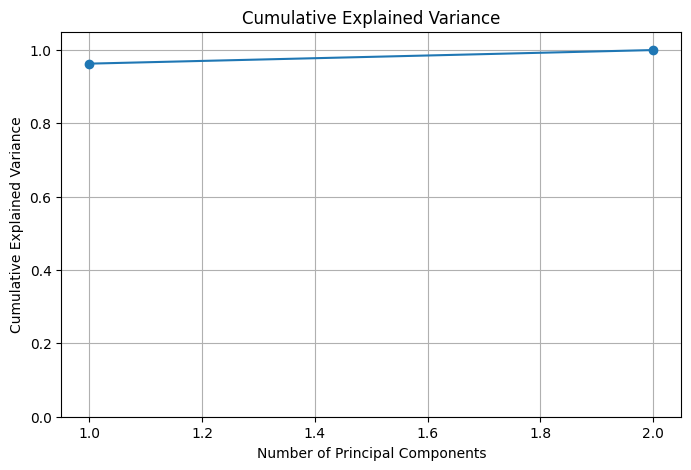

In [10]:
import matplotlib.pyplot as plt

pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.ylim(0, 1.05)
plt.grid()

plt.show()

## Choosing the Number of Principal Components

One important question is:

How many principal components should we keep?

There is no single universal answer.

A common approach is to select enough components to preserve a desired percentage of the total variance.

Typical thresholds include:

- 90%
- 95%
- 99%

For example:

If the first 5 components explain 95% of the variance, we may keep those 5 components instead of all 20 original features.

This provides dimensionality reduction while retaining most of the variance.

The cumulative explained variance curve is commonly used to make this decision.

# PCA on the Iris Dataset

The Iris dataset contains four numerical features:

1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

The goal is to reduce the four-dimensional feature space to two dimensions and visualize the observations.

We will:

1. Load the dataset.
2. Separate features and target.
3. Standardize the features.
4. Apply PCA.
5. Examine explained variance.
6. Visualize the two principal components.

In [11]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(feature_names)

print("\nClasses:")
print(target_names)

Feature Shape: (150, 4)
Target Shape: (150,)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']


## Create DataFrame

In [12]:
df = pd.DataFrame(
    X,
    columns=feature_names
)

df["target"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Standardizing the Iris Features

The four Iris features have different scales and variances.

We standardize them before applying PCA so that each feature contributes on a comparable scale.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Mean of scaled features:")
print(X_scaled.mean(axis=0))

print("\nStandard deviation of scaled features:")
print(X_scaled.std(axis=0))

Mean of scaled features:
[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]

Standard deviation of scaled features:
[1. 1. 1. 1.]


## Apply PCA

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("Reduced Shape:", X_pca.shape)

Original Shape: (150, 4)
Reduced Shape: (150, 2)


## Principal Component Directions

The attribute:

`pca.components_`

contains the directions of the principal components.

Each row corresponds to one principal component.

Each value represents the contribution or loading of an original feature to that component.

In [15]:
components = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=["PC1", "PC2"]
)

components

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
PC1,0.521066,-0.269347,0.580413,0.564857
PC2,0.377418,0.923296,0.024492,0.066942


## Explained Variance Ratio

In [16]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

print("\nTotal Variance Explained:")
print(explained_variance.sum())

Explained Variance Ratio:
[0.72962445 0.22850762]

Total Variance Explained:
0.9581320720000164


## Visualizing Iris After PCA

## Iris Dataset in Two Dimensions

The original Iris dataset contains four numerical dimensions.

PCA transforms these four dimensions into:

PC1

and

PC2

We can now visualize the observations in a two-dimensional plot.

The target labels are used only for visualization.

PCA itself is an unsupervised technique and does not use the target labels when learning the principal components.

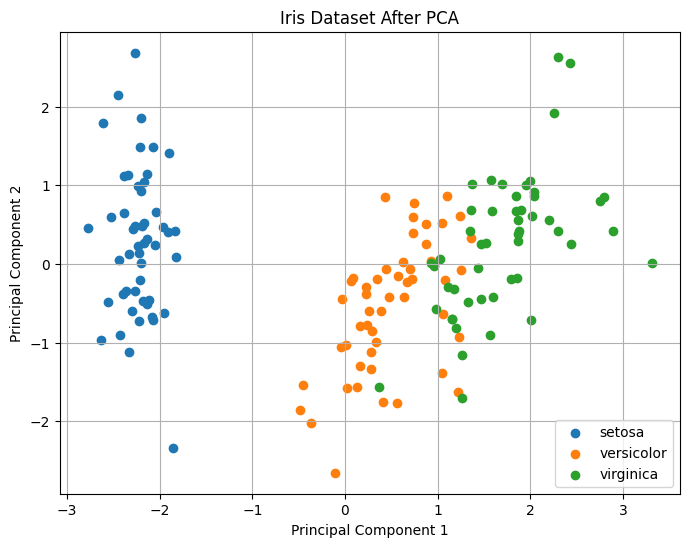

In [17]:
plt.figure(figsize=(8, 6))

for class_index in range(3):
    plt.scatter(
        X_pca[y == class_index, 0],
        X_pca[y == class_index, 1],
        label=target_names[class_index]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset After PCA")
plt.legend()
plt.grid()

plt.show()

## PCA Is Unsupervised

PCA does not require target labels.

During PCA:

X → PCA → Principal Components

The target variable y is not used.

For visualization, however, we can color the transformed points according to their known class labels.

Therefore:

Used for PCA → X

Not used for PCA → y

Used only afterward for visualization → y

## PCA for Dimensionality Reduction

Suppose we have a dataset with 100 features.

We could apply:

PCA(n_components=10)

The resulting dataset would contain only 10 principal components.

Therefore:

Original:

100 features

↓

PCA

↓

10 principal components

If those 10 components preserve most of the important variance, we have achieved substantial dimensionality reduction.

In [18]:
pca_2 = PCA(n_components=2)

X_reduced = pca_2.fit_transform(X_scaled)

print("Original Number of Features:", X_scaled.shape[1])
print("Reduced Number of Features:", X_reduced.shape[1])

Original Number of Features: 4
Reduced Number of Features: 2


## Reconstruction From Principal Components

PCA can also approximately reconstruct the original standardized data.

Suppose we reduce:

4 features → 2 principal components

Some information is lost because we discarded two components.

The inverse transformation attempts to reconstruct the original representation.

The reconstruction is:

X_reconstructed = PCA⁻¹(X_reduced)

The reconstruction will generally not be exactly equal to the original data because dimensionality reduction removes some information.

In [19]:
X_reconstructed = pca.inverse_transform(X_pca)

print("Original scaled data:")
print(X_scaled[:5])

print("\nReconstructed data:")
print(X_reconstructed[:5])

Original scaled data:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]

Reconstructed data:
[[-0.99888895  1.05319838 -1.30270654 -1.24709825]
 [-1.33874781 -0.06192302 -1.22432772 -1.22057235]
 [-1.36096129  0.32111685 -1.38060338 -1.35833824]
 [-1.42359795  0.0677615  -1.34922386 -1.33881298]
 [-1.00113823  1.24091818 -1.37125365 -1.30661752]]


## Reconstruction Error

Because PCA may discard some principal components, the reconstructed data may differ from the original data.

We can measure this difference using Mean Squared Error (MSE).

MSE:

MSE = (1 / n) Σ(xᵢ - x̂ᵢ)²

where:

xᵢ = original value

x̂ᵢ = reconstructed value

A smaller reconstruction error means that the reduced representation preserves more information about the original data.

In [20]:
from sklearn.metrics import mean_squared_error

reconstruction_error = mean_squared_error(
    X_scaled,
    X_reconstructed
)

print("Reconstruction MSE:", reconstruction_error)

Reconstruction MSE: 0.04186792799998358


## Comparing Different Numbers of Components

We can compare PCA models using different numbers of components.

For the Iris dataset:

4 components → No dimensionality reduction

3 components → Small reduction

2 components → Strong reduction

1 component → Very strong reduction

As the number of retained components increases, the reconstruction error generally decreases.

In [21]:
results = []

for n_components in range(1, X_scaled.shape[1] + 1):

    pca_temp = PCA(n_components=n_components)

    X_temp = pca_temp.fit_transform(X_scaled)

    X_reconstructed_temp = pca_temp.inverse_transform(X_temp)

    error = mean_squared_error(
        X_scaled,
        X_reconstructed_temp
    )

    variance = pca_temp.explained_variance_ratio_.sum()

    results.append({
        "Components": n_components,
        "Explained Variance": variance,
        "Reconstruction Error": error
    })

results_df = pd.DataFrame(results)

results_df

,Components,Explained Variance,Reconstruction Error
0,1,0.729624,2.703755e-01
1,2,0.958132,4.186793e-02
2,3,0.994821,5.178709e-03
3,4,1.000000,1.372283e-31


## Plot Explained Variance

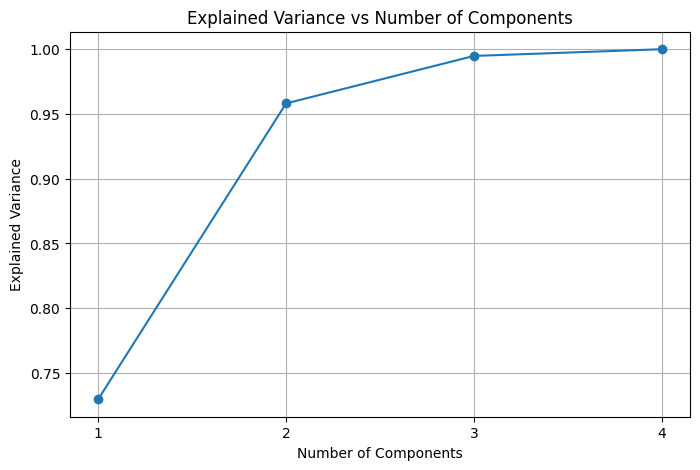

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Components"],
    results_df["Explained Variance"],
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.xticks(results_df["Components"])
plt.grid()

plt.show()

## Plot Reconstruction Error

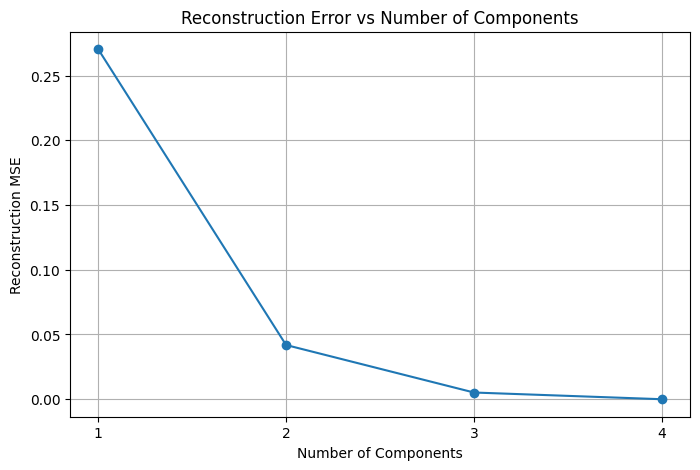

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Components"],
    results_df["Reconstruction Error"],
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Reconstruction MSE")
plt.title("Reconstruction Error vs Number of Components")
plt.xticks(results_df["Components"])
plt.grid()

plt.show()

## PCA With a Variance Threshold

## Automatically Selecting Components Using Explained Variance

Instead of manually specifying the number of components, we can specify the amount of variance we want to preserve.

For example:

PCA(n_components=0.95)

means:

Keep enough principal components to explain at least 95% of the variance.

This is useful when the original dataset contains many features and we do not know beforehand how many components are appropriate.

In [24]:
pca_95 = PCA(n_components=0.95)

X_95 = pca_95.fit_transform(X_scaled)

print("Original Number of Features:", X_scaled.shape[1])
print("Number of Selected Components:", X_95.shape[1])

print("\nExplained Variance:")
print(pca_95.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca_95.explained_variance_ratio_.sum())

Original Number of Features: 4
Number of Selected Components: 2

Explained Variance:
[0.72962445 0.22850762]

Total Explained Variance:
0.9581320720000164


## PCA as a Machine Learning Preprocessing Step

PCA can be used before a machine learning algorithm.

A common pipeline is:

Raw Data
   ↓
Train/Test Split
   ↓
Standardization
   ↓
PCA
   ↓
Machine Learning Model

For example:

Features
   ↓
StandardScaler
   ↓
PCA
   ↓
Logistic Regression

Important:

The scaler and PCA should be fitted only on the training data.

They should then be used to transform the test data.

This prevents data leakage.

## PCA With Pipeline

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    iris.data,
    iris.target,
    test_size=0.2,
    random_state=42,
    stratify=iris.target
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9


## Important Practical Considerations

### 1. PCA Is Linear

PCA finds linear directions in the feature space.

It may not capture complex nonlinear structures.

### 2. PCA Is Sensitive to Scale

Features with larger scales can dominate PCA.

Standardization is often necessary.

### 3. PCA Can Reduce Interpretability

Original features such as:

- Age
- Income
- Height

are easy to interpret.

Principal components are combinations of multiple original features and are therefore harder to interpret.

### 4. PCA Loses Information

If we remove principal components, some information is discarded.

### 5. PCA Is Unsupervised

PCA does not use target labels when finding the principal components.

### 6. PCA Can Be Computationally Expensive

For very large or high-dimensional datasets, specialized approaches such as randomized PCA may be useful.

## Advantages of PCA

1. Reduces dimensionality.

2. Can make high-dimensional data easier to visualize.

3. Can remove redundant information.

4. Produces uncorrelated principal components.

5. Can reduce computational requirements.

6. Can help reduce noise when low-variance components mainly represent noise.

7. Can be useful as a preprocessing technique for machine learning algorithms.

## Limitations of PCA

1. PCA is a linear method.

2. PCA components can be difficult to interpret.

3. PCA is sensitive to feature scaling.

4. PCA can discard useful information.

5. PCA does not consider the target variable.

6. High-variance directions are not necessarily the most useful directions for prediction.

7. PCA can make a model less interpretable even if it improves computational efficiency.

## PCA vs Feature Selection

PCA and feature selection are different.

### Feature Selection

Feature selection chooses some of the original features.

Example:

Original:

X₁, X₂, X₃, X₄, X₅

Feature selection:

X₁, X₃, X₅

The selected features retain their original meaning.

### PCA

PCA creates new features.

Original:

X₁, X₂, X₃, X₄, X₅

PCA:

PC₁, PC₂

PC₁ and PC₂ are combinations of the original features.

Therefore:

Feature Selection → Keeps original features

PCA → Creates new features

## PCA vs Kernel PCA

### PCA

PCA finds linear directions of maximum variance.

It works well when the important structure of the data is approximately linear.

### Kernel PCA

Kernel PCA extends PCA using kernel methods.

It can capture nonlinear structures by implicitly mapping the data into a higher-dimensional feature space.

Therefore:

PCA → Linear dimensionality reduction

Kernel PCA → Nonlinear dimensionality reduction

The next notebook can explore Kernel PCA in more detail.

# Complete PCA Workflow

A typical PCA workflow is:

1. Load the dataset.

2. Separate features from the target when necessary.

3. Split the data into training and testing sets if PCA is being used for machine learning.

4. Standardize the features when their scales differ.

5. Fit PCA on the training data.

6. Examine explained variance.

7. Select an appropriate number of components.

8. Transform the data.

9. Use the transformed data for:
   - Visualization
   - Machine learning
   - Compression
   - Noise reduction

10. Evaluate whether PCA actually improves the intended task.

The important principle is:

**Do not use PCA simply because dimensionality reduction is possible.**

Use PCA when reducing dimensions provides a practical benefit.

# Final Summary

Principal Component Analysis (PCA) is an unsupervised dimensionality reduction technique.

The key ideas are:

- PCA transforms original features into principal components.
- Principal components are linear combinations of the original features.
- PC1 captures the maximum variance.
- PC2 captures the maximum remaining variance while being orthogonal to PC1.
- Eigenvectors determine the directions of the principal components.
- Eigenvalues determine the amount of variance captured.
- Explained variance ratio tells us how much variance each component explains.
- Cumulative explained variance helps us choose the number of components.
- PCA is sensitive to feature scale.
- Standardization is often performed before PCA.
- PCA does not use target labels.
- PCA can be used for visualization and dimensionality reduction.
- PCA may improve computational efficiency but can reduce interpretability.
- PCA is a linear technique.
- Kernel PCA can be used when nonlinear structure is important.

The fundamental PCA transformation is:

X_centered = X - μ

Σ = (1 / (n - 1)) X_centeredᵀ X_centered

Σv = λv

Z = X_centered W

where:

X = original data

μ = feature mean

Σ = covariance matrix

λ = eigenvalue

v = eigenvector

W = selected principal component directions

Z = transformed lower-dimensional representation